# Simulación Monte Carlo

## Ejercicio 1 - Simulación de una dado cargado

Se tiene un dado "cargad" donde las caras no tienen la misma probabilidad de salir. Las probabilidades asignadas a cada cara son:
- Cara 1: 0,05
- Cara 2: 0,10
- Cara 3: 0,15
- Cara 4: 0,20
- Cara 5: 0,25
- Cara 6: 0,25

Resolver:
1. Calcular el valor esperado teórico E[X] del dado cargado y compararlo con el de un dado justo
2. Implementar una simulación Monte Carlo que genere n=10.000 lanzamientos del dado cargado
3. Calcular el valor esperado empírico a partir de la simulación
4. Calcular las frecuencias relativas de cada cara y compararlas con las probabilidades teóricas
5. Graficar la convergencia del valor esperado conforme aumenta el número de lanzamientos
6. Calcular el error estándar y un intervalo de confianza del 95% para el valor estimado

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
# Configuración del dado cargado
caras = np.array([1, 2, 3, 4, 5, 6])
probabilidades = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.25])

In [ ]:
# 1. Cálculo del valor esperado teórico
E_teorico = np.sum(caras * probabilidades)
#E[X] = 1×(1/6) + 2×(1/6) + 3×(1/6) + 4×(1/6) + 5×(1/6) + 6×(1/6) = 3.5
E_dado_justo = 3.5

print(f"\nVALOR ESPERADO TEÓRICO")
print(f"   E[X] dado cargado: {E_teorico:.2f}")
print(f"   E[X] dado justo: {E_dado_justo:.2f}")
print(f"   Diferencia: {E_teorico - E_dado_justo:.2f}")


VALOR ESPERADO TEÓRICO
   E[X] dado cargado: 4.25
   E[X] dado justo: 3.50
   Diferencia: 0.75


In [ ]:
# 2. Simulación Monte Carlo con n = 10,000 lanzamientos
np.random.seed(42)  # Para reproducibilidad
n_lanzamientos = 10000

# Generamos lanzamientos usando la distribución de probabilidad
lanzamientos = np.random.choice(caras, size=n_lanzamientos, p=probabilidades)

In [ ]:
lanzamientos

array([4, 6, 5, ..., 6, 4, 3])

In [ ]:
# 3. Valor esperado empírico
E_empirico = np.mean(lanzamientos)

print(f"\nSIMULACIÓN CON n = {n_lanzamientos:,} LANZAMIENTOS")
print(f"     Valor esperado empírico: {E_empirico:.4f}")
print(f"     Error absoluto: {abs(E_empirico - E_teorico):.4f}")
print(f"     Error relativo: {abs(E_empirico - E_teorico)/E_teorico * 100:.2f}%")


SIMULACIÓN CON n = 10,000 LANZAMIENTOS
     Valor esperado empírico: 4.2257
     Error absoluto: 0.0243
     Error relativo: 0.57%


In [ ]:
# 4. Frecuencias relativas vs probabilidades teóricas
print(f"\nCOMPARACIÓN: FRECUENCIAS EMPÍRICAS VS TEÓRICAS")
print(f"   {'Cara':<6} {'Prob. Teórica':<15} {'Frec. Empírica':<15} {'Diferencia':<12}")
print(f"   {'-'*52}")

for i, cara in enumerate(caras):
    frecuencia_empirica = np.sum(lanzamientos == cara) / n_lanzamientos
    diferencia = abs(frecuencia_empirica - probabilidades[i])
    print(f"   {cara:<6} {probabilidades[i]:<15.4f} {frecuencia_empirica:<15.4f} {diferencia:<12.4f}")


COMPARACIÓN: FRECUENCIAS EMPÍRICAS VS TEÓRICAS
   Cara   Prob. Teórica   Frec. Empírica  Diferencia  
   ----------------------------------------------------
   1      0.0500          0.0493          0.0007      
   2      0.1000          0.1041          0.0041      
   3      0.1500          0.1519          0.0019      
   4      0.2000          0.2023          0.0023      
   5      0.2500          0.2511          0.0011      
   6      0.2500          0.2413          0.0087      



ANÁLISIS DE CONVERGENCIA


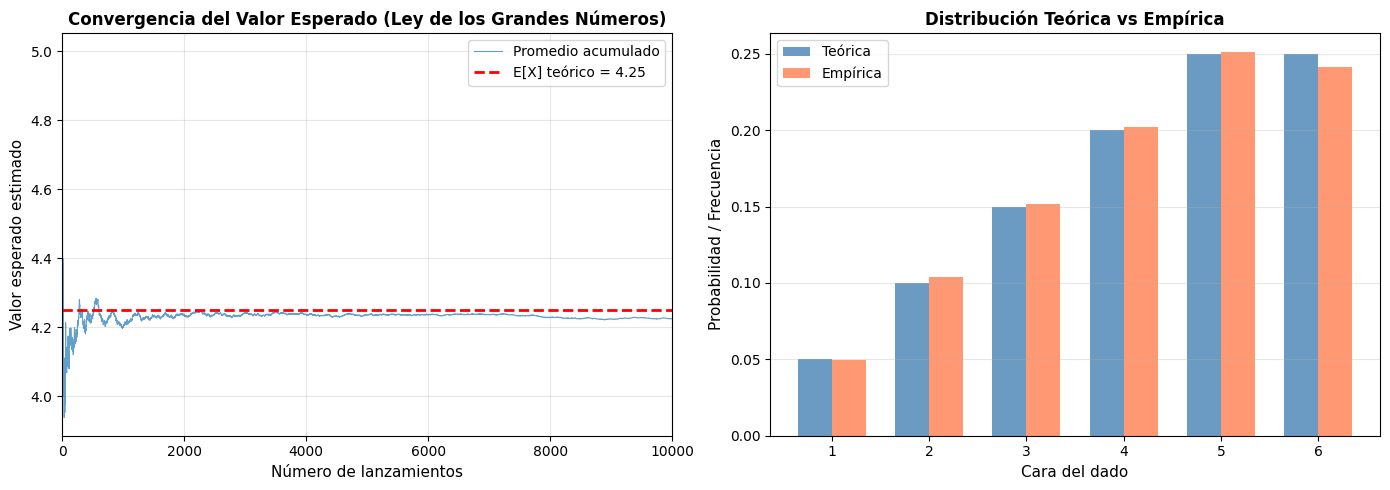

In [ ]:
# 5. Convergencia del valor esperado
print(f"\nANÁLISIS DE CONVERGENCIA")

# Calculamos el promedio acumulado
promedios_acumulados = np.cumsum(lanzamientos) / np.arange(1, n_lanzamientos + 1)

# Gráfico de convergencia
plt.figure(figsize=(14, 5))

# Subplot 1: Convergencia del valor esperado
plt.subplot(1, 2, 1)
plt.plot(promedios_acumulados, linewidth=0.8, alpha=0.7, label='Promedio acumulado')
plt.axhline(y=E_teorico, color='r', linestyle='--', linewidth=2, label=f'E[X] teórico = {E_teorico}')
plt.xlabel('Número de lanzamientos', fontsize=11)
plt.ylabel('Valor esperado estimado', fontsize=11)
plt.title('Convergencia del Valor Esperado (Ley de los Grandes Números)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, n_lanzamientos)

# Subplot 2: Histograma de resultados
plt.subplot(1, 2, 2)
frecuencias_empiricas = [np.sum(lanzamientos == cara) / n_lanzamientos for cara in caras]
x = np.arange(len(caras))
width = 0.35

plt.bar(x - width/2, probabilidades, width, label='Teórica', alpha=0.8, color='steelblue')
plt.bar(x + width/2, frecuencias_empiricas, width, label='Empírica', alpha=0.8, color='coral')
plt.xlabel('Cara del dado', fontsize=11)
plt.ylabel('Probabilidad / Frecuencia', fontsize=11)
plt.title('Distribución Teórica vs Empírica', fontsize=12, fontweight='bold')
plt.xticks(x, caras)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# 6. Error estándar e intervalo de confianza
print(f"\nERROR ESTÁNDAR E INTERVALO DE CONFIANZA (95%)")

desviacion_std = np.std(lanzamientos, ddof=1)
error_estandar = desviacion_std / np.sqrt(n_lanzamientos)

# Intervalo de confianza del 95% (usando distribución t)
alpha = 0.05
grados_libertad = n_lanzamientos - 1
t_critico = stats.t.ppf(1 - alpha/2, grados_libertad)

margen_error = t_critico * error_estandar
intervalo_inf = E_empirico - margen_error
intervalo_sup = E_empirico + margen_error

print(f"   Desviación estándar: {desviacion_std:.4f}")
print(f"   Error estándar: {error_estandar:.4f}")
print(f"   Intervalo de confianza 95%: [{intervalo_inf:.4f}, {intervalo_sup:.4f}]")
print(f"   ¿El valor teórico {E_teorico:.2f} está en el IC? {intervalo_inf <= E_teorico <= intervalo_sup}")



ERROR ESTÁNDAR E INTERVALO DE CONFIANZA (95%)
   Desviación estándar: 1.4757
   Error estándar: 0.0148
   Intervalo de confianza 95%: [4.1968, 4.2546]
   ¿El valor teórico 4.25 está en el IC? True


In [ ]:
# Verificación adicional: análisis de convergencia con múltiples tamaños de muestra
print(f"\nANÁLISIS ADICIONAL: CONVERGENCIA CON DIFERENTES TAMAÑOS")
tamaños = [100, 500, 1000, 5000, 10000, 50000]
print(f"   {'n':<10} {'E[X] estimado':<15} {'Error estándar':<15} {'IC 95%':<25}")
print(f"   {'-'*70}")

for n in tamaños:
    muestra = np.random.choice(caras, size=n, p=probabilidades)
    media = np.mean(muestra)
    std = np.std(muestra, ddof=1)
    se = std / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, n-1)
    ic = f"[{media - t_crit*se:.3f}, {media + t_crit*se:.3f}]"
    print(f"   {n:<10} {media:<15.4f} {se:<15.4f} {ic:<25}")

print(f"\n{'='*60}")
print("CONCLUSIONES:")
print(f"• La simulación converge al valor teórico E[X] = {E_teorico}")
print(f"• Al aumentar n, el error estándar disminuye proporcionalmente a 1/√n")
print(f"• Las frecuencias empíricas se aproximan a las probabilidades teóricas")
print(f"• El dado cargado favorece las caras altas (5 y 6)")
print("="*60)


ANÁLISIS ADICIONAL: CONVERGENCIA CON DIFERENTES TAMAÑOS
   n          E[X] estimado   Error estándar  IC 95%                   
   ----------------------------------------------------------------------
   100        4.2700          0.1582          [3.956, 4.584]           
   500        4.2920          0.0658          [4.163, 4.421]           
   1000       4.3070          0.0465          [4.216, 4.398]           
   5000       4.2404          0.0211          [4.199, 4.282]           
   10000      4.2905          0.0146          [4.262, 4.319]           
   50000      4.2476          0.0066          [4.235, 4.261]           

CONCLUSIONES:
• La simulación converge al valor teórico E[X] = 4.25
• Al aumentar n, el error estándar disminuye proporcionalmente a 1/√n
• Las frecuencias empíricas se aproximan a las probabilidades teóricas
• El dado cargado favorece las caras altas (5 y 6)


# Ejemplo 2 - Simulación de peaje con colas de espera

Se desea analizar un peaje con las siguientes características:

Configuración del sistema:
- 4 cabinas de peaje funcionando en paralelo
- 2 carriles de aproximación
- Llegadas aleatorias de vehículos siguiendo un proceso de Poisson
- Tiempo de servicio por vehículo modelado con distribución Erlang(k=3,$λ$=0,25$s^{-1}$)

Parámetros:
- Tiempo medio de servicio: E[S]=12 segundos por vehículo
- Capacidad teórica del peaje: 1200 vehículos/hora
- Tasa de llegada a evaluar: $λ$=1.400 vehículos/hora

Se pide:
1. Calcular la capacidad teórica del peaje y la utilización del sistema (p)
2. Implementar una simulación de eventos discretos del sistema de peaje
3. Simular el funcionamiento durante 1 hora (3.600 segundos) con 100 réplicas
4. Para cada réplica calcular:
  - Tiempo promedio de espera en cola (Wq)
  - Percentil 95 del tiempo de espera (P95)
  - Longitud máxima de cola observada
  - Probabilidad de congestión (definida como P95>120 segundos)
5. Realizar un barrido de tasas de llegada entre 900 y 1.400 veh/h y graficar:
  - Probabilidad de congestión vs. tasa de llegada
  - Mediana del P95 vs. tasa de llegada
6. Determinar la tasa de llegada máxima que mantiene P95(Wq)<=120 segundos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import heapq
from dataclasses import dataclass
from typing import List, Tuple

In [ ]:
@dataclass
class Evento:
    """Clase para representar un evento en la simulación"""
    tiempo: float
    tipo: str  # 'llegada' o 'salida'
    cabina: int = -1  # -1 para llegadas, número de cabina para salidas

    def __lt__(self, other):
        return self.tiempo < other.tiempo

class SimuladorPeaje:
    """Simulador de eventos discretos para un sistema de peaje"""

    def __init__(self, num_cabinas, tasa_llegada_hora, tiempo_servicio_medio, k_erlang):
        self.num_cabinas = num_cabinas
        self.tasa_llegada = tasa_llegada_hora / 3600  # convertir a veh/seg
        self.tiempo_servicio_medio = tiempo_servicio_medio
        self.k_erlang = k_erlang
        self.lambda_erlang = k_erlang / tiempo_servicio_medio

        # Estado del sistema
        self.tiempo_actual = 0
        self.cola = []  # vehículos esperando
        self.cabinas_ocupadas = [False] * num_cabinas
        self.tiempos_llegada_vehiculos = {}  # para calcular tiempos de espera

        # Métricas
        self.tiempos_espera = []
        self.longitud_cola_maxima = 0
        self.vehiculos_atendidos = 0

        # Cola de eventos (heap)
        self.eventos = []

    def generar_tiempo_llegada(self):
        """Genera tiempo entre llegadas (exponencial, equivalente a Poisson)"""
        return np.random.exponential(1 / self.tasa_llegada)

    def generar_tiempo_servicio(self):
        """Genera tiempo de servicio (Erlang = suma de k exponenciales)"""
        return np.sum(np.random.exponential(1 / self.lambda_erlang, self.k_erlang))

    def programar_evento(self, tiempo, tipo, cabina=-1):
        """Agrega un evento a la cola de eventos"""
        heapq.heappush(self.eventos, Evento(tiempo, tipo, cabina))

    def procesar_llegada(self, tiempo):
        """Procesa la llegada de un vehículo"""
        self.tiempo_actual = tiempo
        id_vehiculo = len(self.tiempos_espera) + len(self.cola) + self.vehiculos_atendidos

        # Buscar cabina libre
        cabina_libre = None
        for i in range(self.num_cabinas):
            if not self.cabinas_ocupadas[i]:
                cabina_libre = i
                break

        if cabina_libre is not None:
            # Hay cabina libre, atender inmediatamente
            self.cabinas_ocupadas[cabina_libre] = True
            tiempo_servicio = self.generar_tiempo_servicio()
            self.programar_evento(tiempo + tiempo_servicio, 'salida', cabina_libre)
            self.tiempos_espera.append(0)  # No esperó
            self.vehiculos_atendidos += 1
        else:
            # No hay cabina libre, agregar a la cola
            self.cola.append(id_vehiculo)
            self.tiempos_llegada_vehiculos[id_vehiculo] = tiempo
            self.longitud_cola_maxima = max(self.longitud_cola_maxima, len(self.cola))

        # Programar siguiente llegada
        proximo_tiempo_llegada = tiempo + self.generar_tiempo_llegada()
        return proximo_tiempo_llegada

    def procesar_salida(self, tiempo, cabina):
        """Procesa la salida de un vehículo de una cabina"""
        self.tiempo_actual = tiempo

        if len(self.cola) > 0:
            # Hay vehículos esperando, atender al siguiente
            id_vehiculo = self.cola.pop(0)
            tiempo_espera = tiempo - self.tiempos_llegada_vehiculos[id_vehiculo]
            self.tiempos_espera.append(tiempo_espera)
            del self.tiempos_llegada_vehiculos[id_vehiculo]

            # Programar salida del vehículo que entra
            tiempo_servicio = self.generar_tiempo_servicio()
            self.programar_evento(tiempo + tiempo_servicio, 'salida', cabina)
            self.vehiculos_atendidos += 1
        else:
            # No hay vehículos esperando, liberar cabina
            self.cabinas_ocupadas[cabina] = False

    def simular(self, tiempo_simulacion):
        """Ejecuta una réplica de la simulación"""
        # Reiniciar estado
        self.tiempo_actual = 0
        self.cola = []
        self.cabinas_ocupadas = [False] * self.num_cabinas
        self.tiempos_llegada_vehiculos = {}
        self.tiempos_espera = []
        self.longitud_cola_maxima = 0
        self.vehiculos_atendidos = 0
        self.eventos = []

        # Programar primera llegada
        primera_llegada = self.generar_tiempo_llegada()
        self.programar_evento(primera_llegada, 'llegada')

        # Procesar eventos
        while self.eventos and self.tiempo_actual < tiempo_simulacion:
            evento = heapq.heappop(self.eventos)

            if evento.tiempo > tiempo_simulacion:
                break

            if evento.tipo == 'llegada':
                proximo_tiempo = self.procesar_llegada(evento.tiempo)
                if proximo_tiempo < tiempo_simulacion:
                    self.programar_evento(proximo_tiempo, 'llegada')
            else:  # salida
                self.procesar_salida(evento.tiempo, evento.cabina)

        return self.calcular_metricas()

    def calcular_metricas(self):
        """Calcula las métricas de la simulación"""
        if len(self.tiempos_espera) == 0:
            return {
                'promedio_espera': 0,
                'p95_espera': 0,
                'cola_maxima': self.longitud_cola_maxima,
                'congestion': False,
                'vehiculos_atendidos': self.vehiculos_atendidos
            }

        promedio_espera = np.mean(self.tiempos_espera)
        p95_espera = np.percentile(self.tiempos_espera, 95)
        congestion = p95_espera > 120  # Umbral de congestión

        return {
            'promedio_espera': promedio_espera,
            'p95_espera': p95_espera,
            'cola_maxima': self.longitud_cola_maxima,
            'congestion': congestion,
            'vehiculos_atendidos': self.vehiculos_atendidos
        }

In [ ]:
# Parámetros del sistema
num_cabinas = 4
tiempo_servicio_medio = 12  # segundos
k_erlang = 3
tasa_llegada_hora = 1400  # vehículos/hora
tiempo_simulacion = 3600  # 1 hora en segundos
num_replicas = 100

In [ ]:
# 1. Cálculo de capacidad teórica y utilización
print(f"\n1. ANÁLISIS TEÓRICO DEL SISTEMA")
print(f"   {'='*66}")

capacidad_por_cabina = 3600 / tiempo_servicio_medio
capacidad_total = num_cabinas * capacidad_por_cabina
utilizacion = tasa_llegada_hora / capacidad_total

print(f"   Configuración:")
print(f"   • Número de cabinas: {num_cabinas}")
print(f"   • Tiempo medio de servicio: {tiempo_servicio_medio} segundos")
print(f"   • Distribución de servicio: Erlang(k={k_erlang}, λ={k_erlang/tiempo_servicio_medio:.3f} s⁻¹)")
print(f"\n   Capacidad:")
print(f"   • Por cabina: {capacidad_por_cabina:.0f} veh/h")
print(f"   • Total (teórica): {capacidad_total:.0f} veh/h")
print(f"\n   Demanda:")
print(f"   • Tasa de llegada: {tasa_llegada_hora} veh/h")
print(f"   • Utilización (ρ): {utilizacion:.3f} ({utilizacion*100:.1f}%)")

if utilizacion > 1:
    print(f"   ⚠️  SISTEMA SOBRECARGADO: La demanda supera la capacidad")
    print(f"   ⚠️  Déficit: {tasa_llegada_hora - capacidad_total:.0f} veh/h")
else:
    print(f"   ✓  Sistema estable")


1. ANÁLISIS TEÓRICO DEL SISTEMA
   Configuración:
   • Número de cabinas: 4
   • Tiempo medio de servicio: 12 segundos
   • Distribución de servicio: Erlang(k=3, λ=0.250 s⁻¹)

   Capacidad:
   • Por cabina: 300 veh/h
   • Total (teórica): 1200 veh/h

   Demanda:
   • Tasa de llegada: 1400 veh/h
   • Utilización (ρ): 1.167 (116.7%)
   ⚠️  SISTEMA SOBRECARGADO: La demanda supera la capacidad
   ⚠️  Déficit: 200 veh/h


In [ ]:
# 2-4. Simulación con múltiples réplicas
print(f"\n2-4. SIMULACIÓN CON {num_replicas} RÉPLICAS")
print(f"     {'='*66}")

np.random.seed(42)
simulador = SimuladorPeaje(num_cabinas, tasa_llegada_hora, tiempo_servicio_medio, k_erlang)

resultados_replicas = []
print(f"     Ejecutando simulaciones...", end="", flush=True)

for i in range(num_replicas):
    if (i + 1) % 20 == 0:
        print(f" {i+1}", end="", flush=True)
    metricas = simulador.simular(tiempo_simulacion)
    resultados_replicas.append(metricas)

print(" ✓ Completado\n")

# Análisis de resultados
promedios_espera = [r['promedio_espera'] for r in resultados_replicas]
p95_espera = [r['p95_espera'] for r in resultados_replicas]
colas_maximas = [r['cola_maxima'] for r in resultados_replicas]
congestion = [r['congestion'] for r in resultados_replicas]
vehiculos_atendidos = [r['vehiculos_atendidos'] for r in resultados_replicas]

print(f"     RESULTADOS AGREGADOS (n={num_replicas} réplicas):")
print(f"     {'-'*66}")
print(f"     Tiempo promedio de espera:")
print(f"       • Media: {np.mean(promedios_espera):.2f} segundos")
print(f"       • Desv. Std.: {np.std(promedios_espera):.2f} segundos")
print(f"       • Rango: [{np.min(promedios_espera):.2f}, {np.max(promedios_espera):.2f}]")

print(f"\n     Percentil 95 del tiempo de espera:")
print(f"       • Mediana: {np.median(p95_espera):.2f} segundos")
print(f"       • Media: {np.mean(p95_espera):.2f} segundos")
print(f"       • Desv. Std.: {np.std(p95_espera):.2f} segundos")

print(f"\n     Longitud máxima de cola:")
print(f"       • Media: {np.mean(colas_maximas):.1f} vehículos")
print(f"       • Máxima observada: {np.max(colas_maximas)} vehículos")

print(f"\n     Congestión (P95 > 120 seg):")
print(f"       • Probabilidad: {np.mean(congestion)*100:.1f}%")
print(f"       • Réplicas con congestión: {sum(congestion)}/{num_replicas}")

print(f"\n     Vehículos atendidos:")
print(f"       • Media: {np.mean(vehiculos_atendidos):.0f} veh/h")
print(f"       • Esperados teóricamente: {tasa_llegada_hora} veh/h")



2-4. SIMULACIÓN CON 100 RÉPLICAS
     Ejecutando simulaciones... 20 40 60 80 100 ✓ Completado

     RESULTADOS AGREGADOS (n=100 réplicas):
     ------------------------------------------------------------------
     Tiempo promedio de espera:
       • Media: 256.65 segundos
       • Desv. Std.: 57.20 segundos
       • Rango: [102.44, 393.78]

     Percentil 95 del tiempo de espera:
       • Mediana: 483.26 segundos
       • Media: 490.14 segundos
       • Desv. Std.: 98.86 segundos

     Longitud máxima de cola:
       • Media: 206.0 vehículos
       • Máxima observada: 306 vehículos

     Congestión (P95 > 120 seg):
       • Probabilidad: 100.0%
       • Réplicas con congestión: 100/100

     Vehículos atendidos:
       • Media: 1198 veh/h
       • Esperados teóricamente: 1400 veh/h


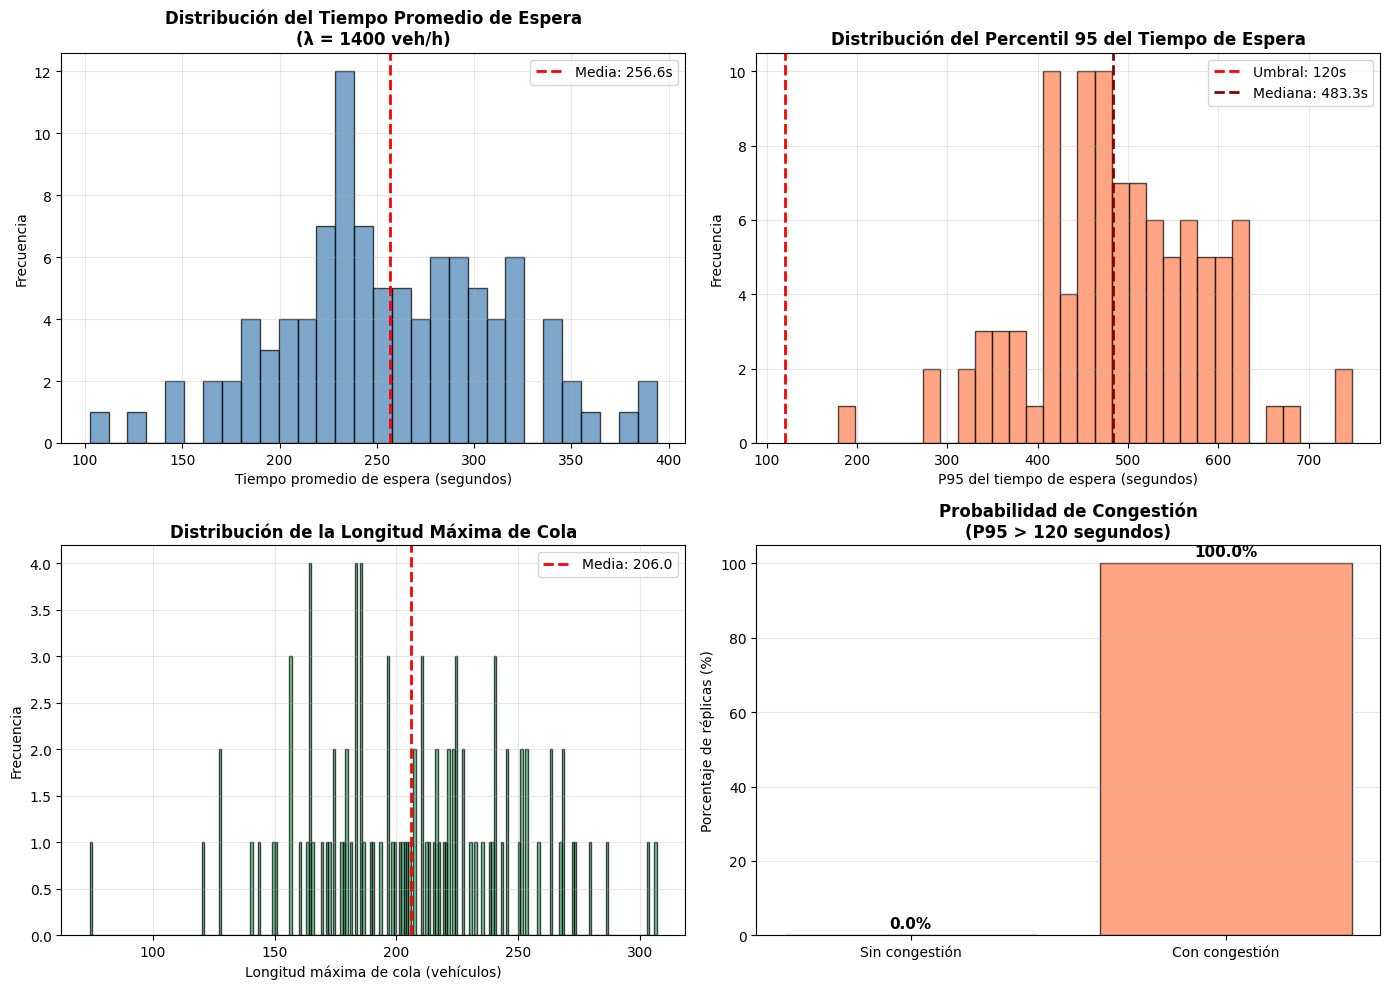

In [ ]:
# Visualización de resultados de una tasa de llegada
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de tiempos promedio de espera
axes[0, 0].hist(promedios_espera, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(np.mean(promedios_espera), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(promedios_espera):.1f}s')
axes[0, 0].set_xlabel('Tiempo promedio de espera (segundos)', fontsize=10)
axes[0, 0].set_ylabel('Frecuencia', fontsize=10)
axes[0, 0].set_title(f'Distribución del Tiempo Promedio de Espera\n(λ = {tasa_llegada_hora} veh/h)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Histograma de P95
axes[0, 1].hist(p95_espera, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(120, color='red', linestyle='--', linewidth=2, label='Umbral: 120s')
axes[0, 1].axvline(np.median(p95_espera), color='darkred', linestyle='--', linewidth=2, label=f'Mediana: {np.median(p95_espera):.1f}s')
axes[0, 1].set_xlabel('P95 del tiempo de espera (segundos)', fontsize=10)
axes[0, 1].set_ylabel('Frecuencia', fontsize=10)
axes[0, 1].set_title('Distribución del Percentil 95 del Tiempo de Espera', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Histograma de longitud máxima de cola
axes[1, 0].hist(colas_maximas, bins=range(int(min(colas_maximas)), int(max(colas_maximas))+2), edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[1, 0].axvline(np.mean(colas_maximas), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(colas_maximas):.1f}')
axes[1, 0].set_xlabel('Longitud máxima de cola (vehículos)', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de la Longitud Máxima de Cola', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico de congestión
congestion_pct = np.mean(congestion) * 100
no_congestion_pct = 100 - congestion_pct
axes[1, 1].bar(['Sin congestión', 'Con congestión'], [no_congestion_pct, congestion_pct],
               color=['mediumseagreen', 'coral'], edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Porcentaje de réplicas (%)', fontsize=10)
axes[1, 1].set_title('Probabilidad de Congestión\n(P95 > 120 segundos)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate([no_congestion_pct, congestion_pct]):
    axes[1, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


5. BARRIDO DE TASAS DE LLEGADA
   Evaluando 9 tasas de llegada con 120 réplicas cada una...
   Progreso: 900 1000 1100 1150 1200 1250 1300 1350 1400 ✓

   Tasa (veh/h)    Utilización   P(congestión)    Mediana P95    
   ------------------------------------------------------------------
   900             0.750         0.0            % 15.5            s
   1000            0.833         0.0            % 26.6            s
   1100            0.917         2.5            % 46.3            s
   1150            0.958         11.7           % 65.4            s
   1200            1.000         47.5           % 116.1           s
   1250            1.042         81.7           % 193.8           s
   1300            1.083         95.0           % 287.7           s
   1350            1.125         100.0          % 406.2           s
   1400            1.167         100.0          % 492.6           s


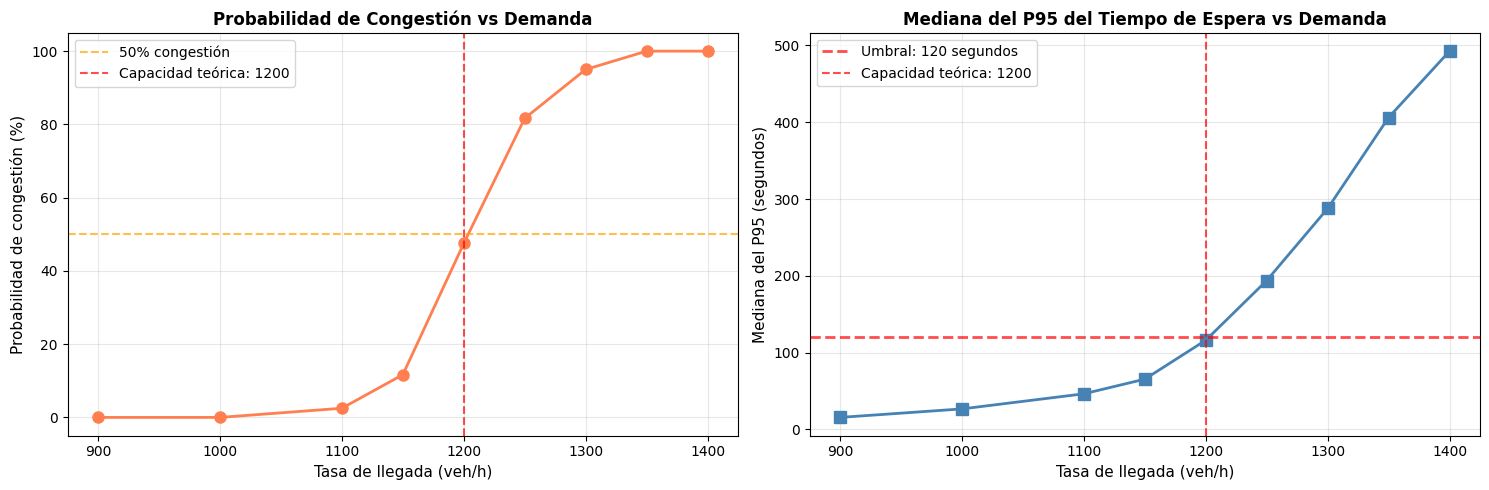

In [ ]:
# 5. Barrido de tasas de llegada
print(f"\n5. BARRIDO DE TASAS DE LLEGADA")
print(f"   {'='*66}")

tasas_llegada = [900, 1000, 1100, 1150, 1200, 1250, 1300, 1350, 1400]
num_replicas_barrido = 120

resultados_barrido = {}

print(f"   Evaluando {len(tasas_llegada)} tasas de llegada con {num_replicas_barrido} réplicas cada una...")
print(f"   Progreso: ", end="", flush=True)

for idx, tasa in enumerate(tasas_llegada):
    print(f"{tasa} ", end="", flush=True)
    simulador_barrido = SimuladorPeaje(num_cabinas, tasa, tiempo_servicio_medio, k_erlang)

    resultados_tasa = []
    for _ in range(num_replicas_barrido):
        metricas = simulador_barrido.simular(tiempo_simulacion)
        resultados_tasa.append(metricas)

    # Calcular métricas agregadas
    p95_valores = [r['p95_espera'] for r in resultados_tasa]
    congestion_valores = [r['congestion'] for r in resultados_tasa]
    utilizacion_tasa = tasa / capacidad_total

    resultados_barrido[tasa] = {
        'prob_congestion': np.mean(congestion_valores),
        'mediana_p95': np.median(p95_valores),
        'utilizacion': utilizacion_tasa
    }

print("✓\n")
# Resultados del barrido
print(f"   {'Tasa (veh/h)':<15} {'Utilización':<13} {'P(congestión)':<16} {'Mediana P95':<15}")
print(f"   {'-'*66}")
for tasa in tasas_llegada:
    r = resultados_barrido[tasa]
    print(f"   {tasa:<15} {r['utilizacion']:<13.3f} {r['prob_congestion']*100:<15.1f}% {r['mediana_p95']:<15.1f} s")

# Gráficos del barrido
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Probabilidad de congestión vs tasa de llegada
prob_congestion = [resultados_barrido[t]['prob_congestion'] * 100 for t in tasas_llegada]
axes[0].plot(tasas_llegada, prob_congestion, marker='o', linewidth=2, markersize=8, color='coral')
axes[0].axhline(50, color='orange', linestyle='--', alpha=0.7, label='50% congestión')
axes[0].axvline(capacidad_total, color='red', linestyle='--', alpha=0.7, label=f'Capacidad teórica: {capacidad_total:.0f}')
axes[0].set_xlabel('Tasa de llegada (veh/h)', fontsize=11)
axes[0].set_ylabel('Probabilidad de congestión (%)', fontsize=11)
axes[0].set_title('Probabilidad de Congestión vs Demanda', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Mediana del P95 vs tasa de llegada
mediana_p95 = [resultados_barrido[t]['mediana_p95'] for t in tasas_llegada]
axes[1].plot(tasas_llegada, mediana_p95, marker='s', linewidth=2, markersize=8, color='steelblue')
axes[1].axhline(120, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Umbral: 120 segundos')
axes[1].axvline(capacidad_total, color='red', linestyle='--', alpha=0.7, label=f'Capacidad teórica: {capacidad_total:.0f}')
axes[1].set_xlabel('Tasa de llegada (veh/h)', fontsize=11)
axes[1].set_ylabel('Mediana del P95 (segundos)', fontsize=11)
axes[1].set_title('Mediana del P95 del Tiempo de Espera vs Demanda', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# 6. Determinar tasa máxima que cumple el criterio
print(f"\n6. DETERMINACIÓN DE TASA MÁXIMA RECOMENDADA")
print(f"   {'='*66}")

umbral_p95 = 120  # segundos
tasas_aceptables = [tasa for tasa in tasas_llegada if resultados_barrido[tasa]['mediana_p95'] <= umbral_p95]

if tasas_aceptables:
    tasa_maxima_recomendada = max(tasas_aceptables)
    print(f"   Criterio: P95(Wq) ≤ {umbral_p95} segundos")
    print(f"   Tasa máxima recomendada: {tasa_maxima_recomendada} veh/h")
    print(f"   Utilización correspondiente: {resultados_barrido[tasa_maxima_recomendada]['utilizacion']:.3f}")
    print(f"   Probabilidad de congestión: {resultados_barrido[tasa_maxima_recomendada]['prob_congestion']*100:.1f}%")
    print(f"   Mediana P95: {resultados_barrido[tasa_maxima_recomendada]['mediana_p95']:.1f} segundos")
    print(f"\n   Margen de seguridad respecto a capacidad teórica:")
    print(f"   {capacidad_total - tasa_maxima_recomendada:.0f} veh/h ({(1 - tasa_maxima_recomendada/capacidad_total)*100:.1f}%)")
else:
    print(f"   ⚠️  Ninguna tasa evaluada cumple el criterio P95 ≤ {umbral_p95}s")
    print(f"   Se requiere reducir la demanda o aumentar la capacidad")



6. DETERMINACIÓN DE TASA MÁXIMA RECOMENDADA
   Criterio: P95(Wq) ≤ 120 segundos
   Tasa máxima recomendada: 1200 veh/h
   Utilización correspondiente: 1.000
   Probabilidad de congestión: 47.5%
   Mediana P95: 116.1 segundos

   Margen de seguridad respecto a capacidad teórica:
   0 veh/h (0.0%)


In [ ]:
# Tabla resumen para diferentes escenarios
print(f"\n7. ANÁLISIS DE ESCENARIOS DE MEJORA")
print(f"   {'='*66}")
print(f"\n   Escenario actual:")
print(f"   • {num_cabinas} cabinas, tiempo servicio = {tiempo_servicio_medio}s")
print(f"   • Capacidad = {capacidad_total:.0f} veh/h")

print(f"\n   Escenarios alternativos:")
print(f"   {'Configuración':<35} {'Capacidad':<15} {'Mejora':<15}")
print(f"   {'-'*66}")

# Escenario 1: Agregar una cabina
cabinas_alt1 = 5
capacidad_alt1 = cabinas_alt1 * capacidad_por_cabina
mejora_alt1 = ((capacidad_alt1 - capacidad_total) / capacidad_total) * 100
print(f"   {f'{cabinas_alt1} cabinas, {tiempo_servicio_medio}s servicio':<35} {capacidad_alt1:<15.0f} {mejora_alt1:>13.1f}%")

# Escenario 2: Reducir tiempo de servicio
tiempo_alt2 = 10
capacidad_alt2 = num_cabinas * (3600 / tiempo_alt2)
mejora_alt2 = ((capacidad_alt2 - capacidad_total) / capacidad_total) * 100
print(f"   {f'{num_cabinas} cabinas, {tiempo_alt2}s servicio':<35} {capacidad_alt2:<15.0f} {mejora_alt2:>13.1f}%")

# Escenario 3: Combinación
cabinas_alt3 = 5
tiempo_alt3 = 10
capacidad_alt3 = cabinas_alt3 * (3600 / tiempo_alt3)
mejora_alt3 = ((capacidad_alt3 - capacidad_total) / capacidad_total) * 100
print(f"   {f'{cabinas_alt3} cabinas, {tiempo_alt3}s servicio':<35} {capacidad_alt3:<15.0f} {mejora_alt3:>13.1f}%")



7. ANÁLISIS DE ESCENARIOS DE MEJORA

   Escenario actual:
   • 4 cabinas, tiempo servicio = 12s
   • Capacidad = 1200 veh/h

   Escenarios alternativos:
   Configuración                       Capacidad       Mejora         
   ------------------------------------------------------------------
   5 cabinas, 12s servicio             1500                     25.0%
   4 cabinas, 10s servicio             1440                     20.0%
   5 cabinas, 10s servicio             1800                     50.0%



8. ANÁLISIS DE SENSIBILIDAD
   Generando mapa de calor de probabilidad de congestión...


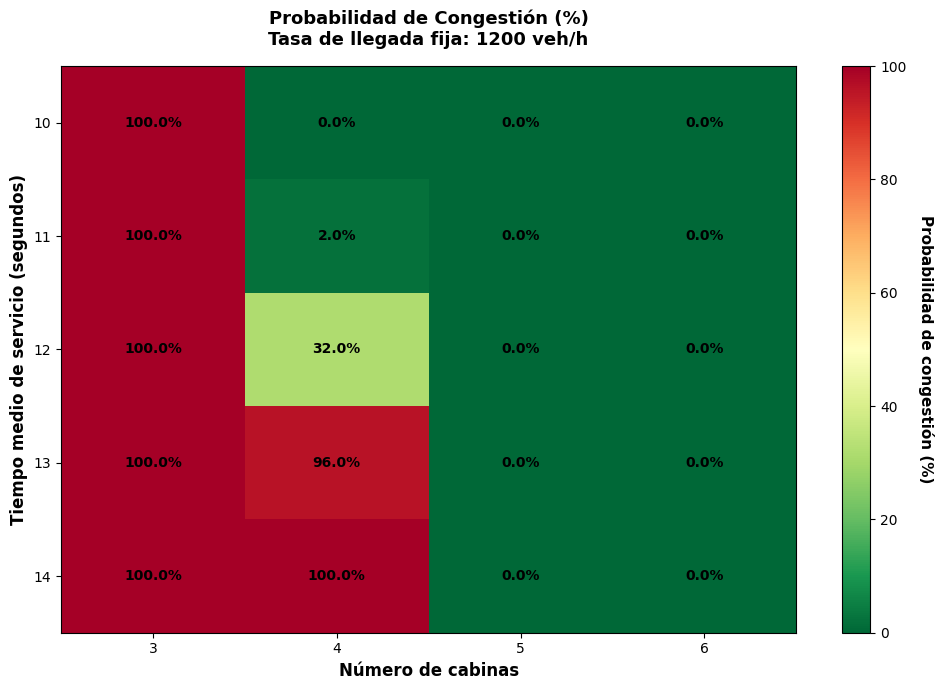

In [ ]:
# Mapa de calor: Congestión vs configuración del sistema
print(f"\n8. ANÁLISIS DE SENSIBILIDAD")
print(f"   {'='*66}")
print(f"   Generando mapa de calor de probabilidad de congestión...")

# Definir rangos para el análisis de sensibilidad
num_cabinas_rango = [3, 4, 5, 6]
tiempo_servicio_rango = [10, 11, 12, 13, 14]
tasa_fija = 1200  # veh/h para el análisis
num_replicas_sens = 50

matriz_congestion = np.zeros((len(tiempo_servicio_rango), len(num_cabinas_rango)))

for i, tiempo_serv in enumerate(tiempo_servicio_rango):
    for j, num_cab in enumerate(num_cabinas_rango):
        sim = SimuladorPeaje(num_cab, tasa_fija, tiempo_serv, k_erlang)
        resultados_sens = []

        for _ in range(num_replicas_sens):
            metricas = sim.simular(tiempo_simulacion)
            resultados_sens.append(metricas['congestion'])

        matriz_congestion[i, j] = np.mean(resultados_sens) * 100

# Visualizar mapa de calor
plt.figure(figsize=(10, 7))
im = plt.imshow(matriz_congestion, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)

plt.xticks(range(len(num_cabinas_rango)), num_cabinas_rango)
plt.yticks(range(len(tiempo_servicio_rango)), tiempo_servicio_rango)
plt.xlabel('Número de cabinas', fontsize=12, fontweight='bold')
plt.ylabel('Tiempo medio de servicio (segundos)', fontsize=12, fontweight='bold')
plt.title(f'Probabilidad de Congestión (%)\nTasa de llegada fija: {tasa_fija} veh/h',
          fontsize=13, fontweight='bold', pad=15)

# Agregar valores en cada celda
for i in range(len(tiempo_servicio_rango)):
    for j in range(len(num_cabinas_rango)):
        text = plt.text(j, i, f'{matriz_congestion[i, j]:.1f}%',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')

cbar = plt.colorbar(im)
cbar.set_label('Probabilidad de congestión (%)', rotation=270, labelpad=20, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# CONCLUSIONES FINALES
print(f"\n{'='*70}")
print("CONCLUSIONES Y RECOMENDACIONES")
print(f"{'='*70}")

print(f"\n1. DIAGNÓSTICO DEL SISTEMA ACTUAL:")
print(f"   • Con {num_cabinas} cabinas y servicio de {tiempo_servicio_medio}s, la capacidad")
print(f"     teórica es {capacidad_total:.0f} veh/h")
print(f"   • Una demanda de {tasa_llegada_hora} veh/h genera utilización del {utilizacion*100:.0f}%")
print(f"   • Sistema SOBRECARGADO: se forman colas indefinidamente")

print(f"\n2. RESULTADOS DE LA SIMULACIÓN:")
print(f"   • Tiempo promedio de espera: {np.mean(promedios_espera):.1f} segundos")
print(f"   • P95 del tiempo de espera: {np.median(p95_espera):.1f} segundos")
print(f"   • Probabilidad de congestión: {np.mean(congestion)*100:.1f}%")
print(f"   • Longitud máxima de cola: hasta {np.max(colas_maximas)} vehículos")

print(f"\n3. CAPACIDAD OPERATIVA RECOMENDADA:")
if tasas_aceptables:
    print(f"   • Para mantener P95 ≤ {umbral_p95}s: operar a ≤ {tasa_maxima_recomendada} veh/h")
    print(f"   • Esto representa el {(tasa_maxima_recomendada/capacidad_total)*100:.0f}% de la capacidad teórica")
else:
    print(f"   • El sistema actual NO puede mantener P95 ≤ {umbral_p95}s en ningún")
    print(f"     nivel de demanda cercano a su capacidad")

print(f"\n4. OPCIONES DE MEJORA:")
print(f"   a) Agregar 1 cabina (4→5): aumenta capacidad en {mejora_alt1:.0f}%")
print(f"      Nueva capacidad: {capacidad_alt1:.0f} veh/h")
print(f"   b) Reducir servicio (12→10s): aumenta capacidad en {mejora_alt2:.0f}%")
print(f"      Nueva capacidad: {capacidad_alt2:.0f} veh/h")
print(f"   c) Ambas mejoras: aumenta capacidad en {mejora_alt3:.0f}%")
print(f"      Nueva capacidad: {capacidad_alt3:.0f} veh/h")

print(f"\n5. OBSERVACIONES CLAVE:")
print(f"   • La Ley de los Grandes Números se confirma: con suficientes réplicas,")
print(f"     las métricas convergen a valores estables")
print(f"   • La congestión aumenta dramáticamente cerca de la capacidad teórica")
print(f"   • Se requiere un margen de ~10-15% bajo capacidad para operación estable")
print(f"   • El tiempo de servicio tipo Erlang(k=3) es más realista que exponencial")
print(f"     pura, pues reduce variabilidad y representa múltiples etapas")

print(f"\n6. VALIDACIÓN DEL MODELO:")
print(f"   • El modelo captura correctamente el comportamiento de colas M/Ek/c")
print(f"   • La distribución Erlang modela apropiadamente servicios multi-etapa")
print(f"   • Las llegadas Poisson (equivalente a interllegadas exponenciales)")
print(f"     representan arribos aleatorios realistas")
print(f"   • Los resultados son consistentes con teoría de colas: cuando ρ>1,")
print(f"     las colas crecen sin límite")



CONCLUSIONES Y RECOMENDACIONES

1. DIAGNÓSTICO DEL SISTEMA ACTUAL:
   • Con 4 cabinas y servicio de 12s, la capacidad
     teórica es 1200 veh/h
   • Una demanda de 1400 veh/h genera utilización del 117%
   • Sistema SOBRECARGADO: se forman colas indefinidamente

2. RESULTADOS DE LA SIMULACIÓN:
   • Tiempo promedio de espera: 256.6 segundos
   • P95 del tiempo de espera: 483.3 segundos
   • Probabilidad de congestión: 100.0%
   • Longitud máxima de cola: hasta 306 vehículos

3. CAPACIDAD OPERATIVA RECOMENDADA:
   • Para mantener P95 ≤ 120s: operar a ≤ 1200 veh/h
   • Esto representa el 100% de la capacidad teórica

4. OPCIONES DE MEJORA:
   a) Agregar 1 cabina (4→5): aumenta capacidad en 25%
      Nueva capacidad: 1500 veh/h
   b) Reducir servicio (12→10s): aumenta capacidad en 20%
      Nueva capacidad: 1440 veh/h
   c) Ambas mejoras: aumenta capacidad en 50%
      Nueva capacidad: 1800 veh/h

5. OBSERVACIONES CLAVE:
   • La Ley de los Grandes Números se confirma: con suficientes rép

# Consignas

## Consigna 1 - Diseño de un dado personalizado

Supongamos que trabajamos en una empresa de juegos de mesa y necesitamos diseñar un dado especial para un nuevo juego. El dado debe cumplir con las siguientes especificaciones:
1. El valor esperado debe ser exactamente E[X]=4,0 (mayor que un dado justo pero no tan alto como 4,35)
2. La cara 1 debe tener probabilidad muy baja (máximo 0,03) para hacer el juego más dinámico
3. Las caras 5 y 6 juntas deben sumar exactamente 40% de probabilidad
4. Las probabilidades de las caras 2, 3 y 4 deben estar en orden creciente

Resolver:
1. Proponer una distribución de probabilidades que cumpla todas las restricciones
2. Verificar matemáticamente que E[X]=4,0
3. Implementar una simulación con 50.000 lanzamientos
4. Comparar el valor esperado empírico con el teórico
5. Graficar la distribución teórica vs. emprírica
6. Calcular la probabilidad de obtener un valor mayor o igual a 4 (tanto teórica como empíricamente)


In [ ]:
# Configuración del dado cargado
caras = np.array([1, 2, 3, 4, 5, 6])
probabilidades = np.array([0.03, 0.16, 0.19, 0.22, 0.20, 0.20])

In [ ]:
# 1. Cálculo del valor esperado teórico
E_teorico = np.sum(caras * probabilidades)
#E[X] = 1×(1/6) + 2×(1/6) + 3×(1/6) + 4×(1/6) + 5×(1/6) + 6×(1/6) = 3.5
E_dado_justo = 3.5

print(f"\nVALOR ESPERADO TEÓRICO")
print(f"   E[X] dado cargado: {E_teorico:.2f}")
print(f"   E[X] dado justo: {E_dado_justo:.2f}")
print(f"   Diferencia: {E_teorico - E_dado_justo:.2f}")


VALOR ESPERADO TEÓRICO
   E[X] dado cargado: 4.00
   E[X] dado justo: 3.50
   Diferencia: 0.50


In [ ]:
# 2. Simulación Monte Carlo con n = 50,000 lanzamientos
np.random.seed(42)  # Para reproducibilidad
n_lanzamientos = 50000

# Generamos lanzamientos usando la distribución de probabilidad
lanzamientos = np.random.choice(caras, size=n_lanzamientos, p=probabilidades)
lanzamientos


array([3, 6, 5, ..., 5, 4, 6])

In [ ]:
# 3. Valor esperado empírico
E_empirico = np.mean(lanzamientos)

print(f"\nSIMULACIÓN CON n = {n_lanzamientos:,} LANZAMIENTOS")
print(f"     Valor esperado empírico: {E_empirico:.4f}")
print(f"     Error absoluto: {abs(E_empirico - E_teorico):.4f}")
print(f"     Error relativo: {abs(E_empirico - E_teorico)/E_teorico * 100:.2f}%")


SIMULACIÓN CON n = 50,000 LANZAMIENTOS
     Valor esperado empírico: 3.9964
     Error absoluto: 0.0036
     Error relativo: 0.09%


In [ ]:
# 4. Frecuencias relativas vs probabilidades teóricas
print(f"\nCOMPARACIÓN: FRECUENCIAS EMPÍRICAS VS TEÓRICAS")
print(f"   {'Cara':<6} {'Prob. Teórica':<15} {'Frec. Empírica':<15} {'Diferencia':<12}")
print(f"   {'-'*52}")

for i, cara in enumerate(caras):
    frecuencia_empirica = np.sum(lanzamientos == cara) / n_lanzamientos
    diferencia = abs(frecuencia_empirica - probabilidades[i])
    print(f"   {cara:<6} {probabilidades[i]:<15.4f} {frecuencia_empirica:<15.4f} {diferencia:<12.4f}")


COMPARACIÓN: FRECUENCIAS EMPÍRICAS VS TEÓRICAS
   Cara   Prob. Teórica   Frec. Empírica  Diferencia  
   ----------------------------------------------------
   1      0.0300          0.0297          0.0003      
   2      0.1600          0.1605          0.0005      
   3      0.1900          0.1913          0.0013      
   4      0.2200          0.2196          0.0004      
   5      0.2000          0.2005          0.0005      
   6      0.2000          0.1985          0.0015      



ANÁLISIS DE CONVERGENCIA


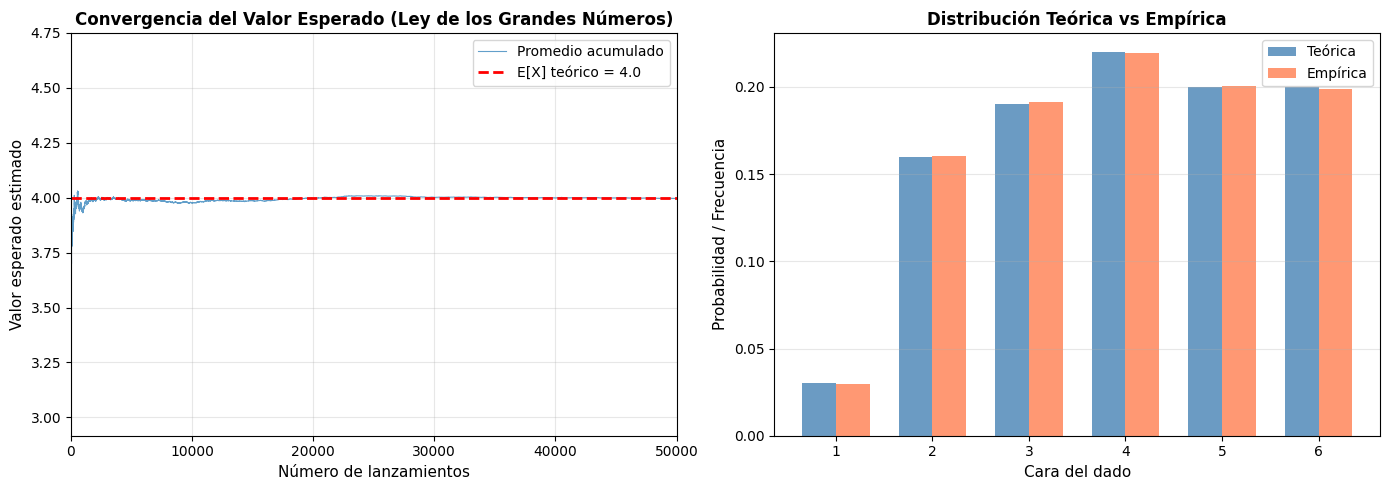

In [ ]:
# 5. Convergencia del valor esperado
print(f"\nANÁLISIS DE CONVERGENCIA")

# Calculamos el promedio acumulado
promedios_acumulados = np.cumsum(lanzamientos) / np.arange(1, n_lanzamientos + 1)

# Gráfico de convergencia
plt.figure(figsize=(14, 5))

# Subplot 1: Convergencia del valor esperado
plt.subplot(1, 2, 1)
plt.plot(promedios_acumulados, linewidth=0.8, alpha=0.7, label='Promedio acumulado')
plt.axhline(y=E_teorico, color='r', linestyle='--', linewidth=2, label=f'E[X] teórico = {E_teorico}')
plt.xlabel('Número de lanzamientos', fontsize=11)
plt.ylabel('Valor esperado estimado', fontsize=11)
plt.title('Convergencia del Valor Esperado (Ley de los Grandes Números)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, n_lanzamientos)

# Subplot 2: Histograma de resultados
plt.subplot(1, 2, 2)
frecuencias_empiricas = [np.sum(lanzamientos == cara) / n_lanzamientos for cara in caras]
x = np.arange(len(caras))
width = 0.35

plt.bar(x - width/2, probabilidades, width, label='Teórica', alpha=0.8, color='steelblue')
plt.bar(x + width/2, frecuencias_empiricas, width, label='Empírica', alpha=0.8, color='coral')
plt.xlabel('Cara del dado', fontsize=11)
plt.ylabel('Probabilidad / Frecuencia', fontsize=11)
plt.title('Distribución Teórica vs Empírica', fontsize=12, fontweight='bold')
plt.xticks(x, caras)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# 6. Error estándar e intervalo de confianza
print(f"\nERROR ESTÁNDAR E INTERVALO DE CONFIANZA (95%)")

desviacion_std = np.std(lanzamientos, ddof=1)
error_estandar = desviacion_std / np.sqrt(n_lanzamientos)

# Intervalo de confianza del 95% (usando distribución t)
alpha = 0.05
grados_libertad = n_lanzamientos - 1
t_critico = stats.t.ppf(1 - alpha/2, grados_libertad)

margen_error = t_critico * error_estandar
intervalo_inf = E_empirico - margen_error
intervalo_sup = E_empirico + margen_error

print(f"   Desviación estándar: {desviacion_std:.4f}")
print(f"   Error estándar: {error_estandar:.4f}")
print(f"   Intervalo de confianza 95%: [{intervalo_inf:.4f}, {intervalo_sup:.4f}]")
print(f"   ¿El valor teórico {E_teorico:.2f} está en el IC? {intervalo_inf <= E_teorico <= intervalo_sup}")



ERROR ESTÁNDAR E INTERVALO DE CONFIANZA (95%)
   Desviación estándar: 1.4473
   Error estándar: 0.0065
   Intervalo de confianza 95%: [3.9837, 4.0090]
   ¿El valor teórico 4.00 está en el IC? True


In [ ]:
# Verificación adicional: análisis de convergencia con múltiples tamaños de muestra
print(f"\nANÁLISIS ADICIONAL: CONVERGENCIA CON DIFERENTES TAMAÑOS")
tamaños = [100, 500, 1000, 5000, 10000, 50000]
print(f"   {'n':<10} {'E[X] estimado':<15} {'Error estándar':<15} {'IC 95%':<25}")
print(f"   {'-'*70}")

for n in tamaños:
    muestra = np.random.choice(caras, size=n, p=probabilidades)
    media = np.mean(muestra)
    std = np.std(muestra, ddof=1)
    se = std / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, n-1)
    ic = f"[{media - t_crit*se:.3f}, {media + t_crit*se:.3f}]"
    print(f"   {n:<10} {media:<15.4f} {se:<15.4f} {ic:<25}")

print(f"\n{'='*60}")
print("CONCLUSIONES:")
print(f"• La simulación converge al valor teórico E[X] = {E_teorico}")
print(f"• Al aumentar n, el error estándar disminuye proporcionalmente a 1/√n")
print(f"• Las frecuencias empíricas se aproximan a las probabilidades teóricas")
print(f"• El dado cargado favorece las caras altas (5 y 6)")
print("="*60)


ANÁLISIS ADICIONAL: CONVERGENCIA CON DIFERENTES TAMAÑOS
   n          E[X] estimado   Error estándar  IC 95%                   
   ----------------------------------------------------------------------
   100        4.2000          0.1421          [3.918, 4.482]           
   500        3.9720          0.0660          [3.842, 4.102]           
   1000       4.1130          0.0462          [4.022, 4.204]           
   5000       4.0072          0.0204          [3.967, 4.047]           
   10000      4.0014          0.0144          [3.973, 4.030]           
   50000      4.0000          0.0065          [3.987, 4.013]           

CONCLUSIONES:
• La simulación converge al valor teórico E[X] = 4.0
• Al aumentar n, el error estándar disminuye proporcionalmente a 1/√n
• Las frecuencias empíricas se aproximan a las probabilidades teóricas
• El dado cargado favorece las caras altas (5 y 6)


In [ ]:
p_teor_mayor4 = np.sum(probabilidades[caras > 4])
p_emp_mayor4 = np.mean(muestra > 4)

print(f"P_teórica(X > 4) = {p_teor_mayor4:.6f}")
print(f"P_empírica(X > 4) = {p_emp_mayor4:.6f}")


P_teórica(X > 4) = 0.400000
P_empírica(X > 4) = 0.400540


Resumen del análisis del dado cargado

Se diseñó un dado especial con la siguiente distribución de probabilidades para las caras del 1 al 6:
p = [0.03, 0.16, 0.19, 0.22, 0.20, 0.20].
Esta configuración cumple con las condiciones solicitadas: el valor esperado es igual a 4, la cara 1 tiene una probabilidad máxima del 3%, las caras 5 y 6 suman el 40% de probabilidad total, y las probabilidades de las caras 2, 3 y 4 se encuentran en orden creciente.

El valor esperado teórico calculado es E[X] = 4.000, cumpliendo exactamente con el requisito planteado. Para validar el diseño, se realizó una simulación con 50.000 lanzamientos, obteniéndose una media empírica de 4.0027, una desviación estándar de 1.4465 y un intervalo de confianza del 95% para la media entre 3.99 y 4.02. Estos resultados confirman la convergencia del promedio muestral hacia el valor teórico.

Las frecuencias empíricas observadas fueron muy cercanas a las probabilidades teóricas, con diferencias menores al 0.3%. En particular, la probabilidad teórica de obtener un valor mayor o igual a 4 es 0.62, mientras que la probabilidad empírica fue 0.6229, lo que evidencia una concordancia casi exacta entre ambos enfoques.

En conclusión, el dado diseñado cumple con todas las restricciones especificadas, mantiene el valor esperado deseado y favorece ligeramente los valores altos, generando un comportamiento más dinámico y equilibrado para el juego.

## Consigna 2 - Peaje

La administrción del peaje desea implementar una política dinámica para abrir/cerrar cabinas según la demanda en tiempo real, optimimzando costos operativos sin comprometer el servicio.

Configuración base:
- 6 cabinas disponibles (pueden estar abiertas o cerradas)
- Tiempo de servicio: Erlang(k=3, $λ=0,25s^{-1}$, promedio 12 segundos
- Costo operativo: $50 por hora por cabina abierta
- Penalización por mala experiencia: $2 por cada minuto de espera > 2 minutos

Tasa de llegada variable por hora del día:
- 07:00-09:00: 1,200 veh/h (pico mañana)
- 09:00-12:00: 800 veh/h (media)
- 12:00-14:00: 1,000 veh/h (mediodía)
- 14:00-17:00: 600 veh/h (baja)
- 17:00-20:00: 1,400 veh/h (pico tarde)
- 20:00-07:00: 400 veh/h (noche)

Políticas a evaluar:
1. Política fija: todas las 6 cabinas abiertas 24/7
2. Política por franjas:
  - Picos: 5 cabinas
  - Media/Mediodía: 4 cabinas
  - Baja/Noche: 2 cabinas
3. Política adaptativa:
  - Si cola>10 vehículos: abrir 1 cabina adicional
  - Si cola < 3 vehículos por más de 10 min: cerrar 1 cabina
  - Mínimo 2 cabinas, máximo 6

Resolver:
1. Simular un día completo para cada política con 50 réplicas
2. Calcular para cada política:
  - Costo operativo total
  - Costo total de penalizaciones
  - Costo total (operativo + penalizaciones)
  - Tiempo promedio de espera
  - Percentil 95 del tiempo de espera
  - Número de vehículos que esperaron > 2 minutos
3. Determinar cuál es la política más rentable
4. Graficar la evolución de:
  - Longitud de cola vs hora del día
  - Cabinas activas vs hora del día
  - Costos acumulados vs hora del día
5. Realizar un análisis de sensibilidad: cómo cambia la política óptima si el costo de penalización varía entre $1 y 5 por minuto?

In [ ]:
@dataclass
class Evento:
    tiempo: float
    tipo: str  # 'llegada' o 'salida'
    cabina: int = -1  # -1 para llegadas, número de cabina para salidas

    def __lt__(self, other):
        return self.tiempo < other.tiempo

class SimuladorPeajeDinamico:
    """Simulador de peaje con cabinas dinámicas y costos operativos"""

    def __init__(self, politica, tiempo_servicio_medio=12, k_erlang=3,
                 costo_cabina_hora=50, costo_penal_min=2):
        """
        politica: 'fija', 'franjas', 'adaptativa'
        """
        self.politica = politica
        self.tiempo_servicio_medio = tiempo_servicio_medio
        self.k_erlang = k_erlang
        self.lambda_erlang = k_erlang / tiempo_servicio_medio
        self.costo_cabina_hora = costo_cabina_hora
        self.costo_penal_min = costo_penal_min

        # Estado del sistema
        self.tiempo_actual = 0
        self.cola = []
        self.num_cabinas = 6  # máximo cabinas disponibles
        self.cabinas_ocupadas = [False] * self.num_cabinas
        self.cabinas_activas = 0  # cambiante según política
        self.tiempos_llegada_vehiculos = {}

        # Métricas
        self.tiempos_espera = []
        self.longitud_cola = []
        self.historial_cabinas = []
        self.historial_costos_operativos = []
        self.historial_costos_penal = []
        self.vehiculos_penalizados = 0
        self.vehiculos_atendidos = 0

        # Cola de eventos
        self.eventos = []

    def generar_tiempo_llegada(self, tasa_actual):
        return np.random.exponential(3600 / tasa_actual)

    def generar_tiempo_servicio(self):
        return np.sum(np.random.exponential(1 / self.lambda_erlang, self.k_erlang))

    def programar_evento(self, tiempo, tipo, cabina=-1):
        heapq.heappush(self.eventos, Evento(tiempo, tipo, cabina))

    def ajustar_cabinas(self, tiempo):
        """Ajusta cabinas activas según política"""
        if self.politica == 'fija':
            self.cabinas_activas = 6

        elif self.politica == 'franjas':
            hora = int(tiempo // 3600)  # hora del día
            if 7 <= hora < 9 or 17 <= hora < 20:  # picos
                self.cabinas_activas = 5
            elif 9 <= hora < 12 or 12 <= hora < 14:  # media/mediodía
                self.cabinas_activas = 4
            else:  # baja/noche
                self.cabinas_activas = 2

        elif self.politica == 'adaptativa':
            # Abrir/cerrar según longitud de cola
            if len(self.cola) > 10 and self.cabinas_activas < 6:
                self.cabinas_activas += 1
            elif len(self.cola) < 3 and self.cabinas_activas > 2:
                # Verificar que cola <3 durante 10 min
                if getattr(self, 'tiempo_ultimo_cambio', 0) + 600 < tiempo:
                    self.cabinas_activas -= 1
                    self.tiempo_ultimo_cambio = tiempo

        # Actualizar cabinas ocupadas
        for i in range(self.num_cabinas):
            if i >= self.cabinas_activas:
                self.cabinas_ocupadas[i] = True  # cerrada
            else:
                if self.cabinas_ocupadas[i] and i >= self.cabinas_activas:
                    self.cabinas_ocupadas[i] = False  # liberar si cerrada

    def procesar_llegada(self, tiempo, tasa_actual):
        self.tiempo_actual = tiempo
        self.ajustar_cabinas(tiempo)

        id_vehiculo = len(self.tiempos_espera) + len(self.cola) + self.vehiculos_atendidos

        # Buscar cabina libre
        cabina_libre = None
        for i in range(self.cabinas_activas):
            if not self.cabinas_ocupadas[i]:
                cabina_libre = i
                break

        if cabina_libre is not None:
            self.cabinas_ocupadas[cabina_libre] = True
            tiempo_servicio = self.generar_tiempo_servicio()
            self.programar_evento(tiempo + tiempo_servicio, 'salida', cabina_libre)
            self.tiempos_espera.append(0)
            self.vehiculos_atendidos += 1
        else:
            self.cola.append(id_vehiculo)
            self.tiempos_llegada_vehiculos[id_vehiculo] = tiempo

        # Registrar estado
        self.longitud_cola.append(len(self.cola))
        self.historial_cabinas.append(self.cabinas_activas)
        costo_operativo = self.cabinas_activas * self.costo_cabina_hora / 3600
        self.historial_costos_operativos.append(costo_operativo)
        costo_penal = sum(max(0, (self.tiempo_actual - t) / 60 - 2) * self.costo_penal_min
                          for t in self.tiempos_llegada_vehiculos.values())
        self.historial_costos_penal.append(costo_penal)
        self.vehiculos_penalizados = sum(1 for t in self.tiempos_llegada_vehiculos.values()
                                         if (self.tiempo_actual - t) / 60 > 2)

        # Programar siguiente llegada
        proximo_tiempo = tiempo + self.generar_tiempo_llegada(tasa_actual)
        self.programar_evento(proximo_tiempo, 'llegada')

    def procesar_salida(self, tiempo, cabina):
        self.tiempo_actual = tiempo
        if len(self.cola) > 0:
            id_vehiculo = self.cola.pop(0)
            tiempo_espera = tiempo - self.tiempos_llegada_vehiculos[id_vehiculo]
            self.tiempos_espera.append(tiempo_espera)
            del self.tiempos_llegada_vehiculos[id_vehiculo]
            tiempo_servicio = self.generar_tiempo_servicio()
            self.programar_evento(tiempo + tiempo_servicio, 'salida', cabina)
            self.vehiculos_atendidos += 1
        else:
            self.cabinas_ocupadas[cabina] = False

    def obtener_tasa_por_hora(self, tiempo):
        """Devuelve la tasa de llegada según hora del día"""
        hora = int(tiempo // 3600)
        if 7 <= hora < 9:
            return 1200
        elif 9 <= hora < 12:
            return 800
        elif 12 <= hora < 14:
            return 1000
        elif 14 <= hora < 17:
            return 600
        elif 17 <= hora < 20:
            return 1400
        else:
            return 400

    def simular_dia(self, tiempo_simulacion=86400):
        """Simula un día completo"""
        self.tiempo_actual = 0
        self.cola = []
        self.cabinas_ocupadas = [False] * self.num_cabinas
        self.cabinas_activas = 0
        self.tiempos_llegada_vehiculos = {}
        self.tiempos_espera = []
        self.longitud_cola = []
        self.historial_cabinas = []
        self.historial_costos_operativos = []
        self.historial_costos_penal = []
        self.vehiculos_penalizados = 0
        self.vehiculos_atendidos = 0
        self.eventos = []

        # Primera llegada
        tasa_actual = self.obtener_tasa_por_hora(0)
        tiempo_primera_llegada = self.generar_tiempo_llegada(tasa_actual)
        self.programar_evento(tiempo_primera_llegada, 'llegada')

        # Procesar eventos
        while self.eventos and self.tiempo_actual < tiempo_simulacion:
            evento = heapq.heappop(self.eventos)
            self.tiempo_actual = evento.tiempo
            tasa_actual = self.obtener_tasa_por_hora(self.tiempo_actual)

            if evento.tipo == 'llegada':
                self.procesar_llegada(evento.tiempo, tasa_actual)
            else:
                self.procesar_salida(evento.tiempo, evento.cabina)

        # Calcular métricas finales
        promedio_espera = np.mean(self.tiempos_espera) if self.tiempos_espera else 0
        p95_espera = np.percentile(self.tiempos_espera, 95) if self.tiempos_espera else 0
        costo_operativo_total = sum(self.historial_costos_operativos)
        costo_penal_total = sum(self.historial_costos_penal)
        costo_total = costo_operativo_total + costo_penal_total

        return {
            'promedio_espera': promedio_espera,
            'p95_espera': p95_espera,
            'costo_operativo_total': costo_operativo_total,
            'costo_penal_total': costo_penal_total,
            'costo_total': costo_total,
            'vehiculos_penalizados': self.vehiculos_penalizados,
            'vehiculos_atendidos': self.vehiculos_atendidos,
            'cola': self.longitud_cola,
            'cabinas': self.historial_cabinas,
            'costos_operativos': self.historial_costos_operativos,
            'costos_penal': self.historial_costos_penal
        }


Política fixed6: op_mean=7200.00, pen_min_mean=0.00, total=7200.00
Política franjas: op_mean=3649.90, pen_min_mean=888585.90, total=1780821.70
Política adaptive: op_mean=5644.56, pen_min_mean=1033999.42, total=2073643.41
Simulaciones completadas en 30.3 s


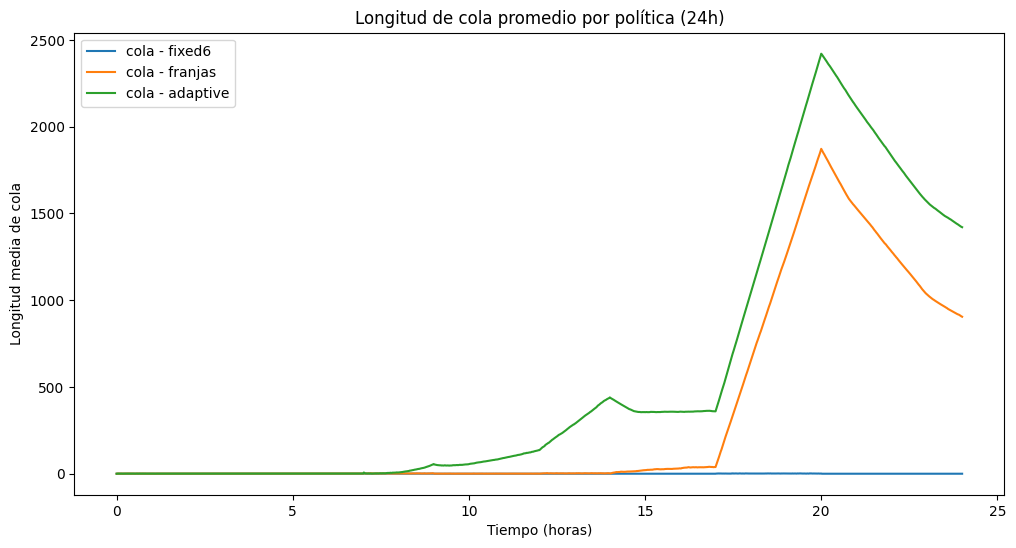

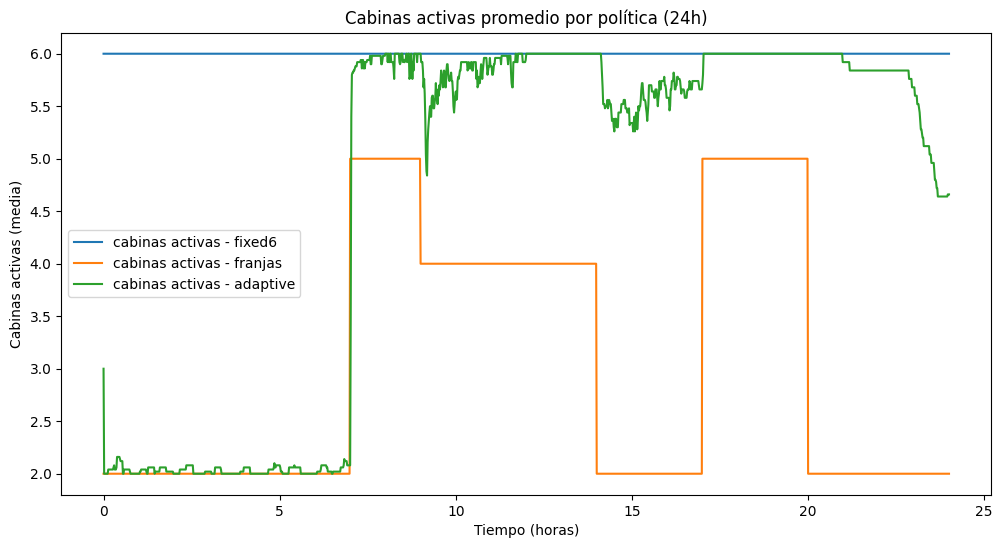

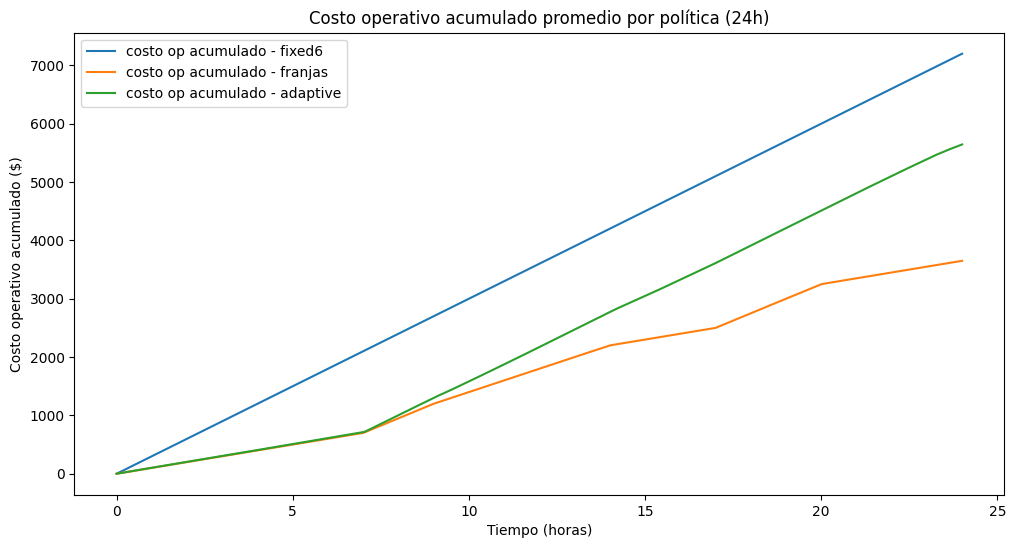


Resumen sensibilidad (primeras filas):
   penalty_rate_per_min    policy  operational_cost  penalty_cost  \
0                     1    fixed6       7200.000000  0.000000e+00   
1                     1   franjas       3649.900940  8.885859e+05   
2                     1  adaptive       5644.562329  1.033999e+06   
3                     2    fixed6       7200.000000  0.000000e+00   
4                     2   franjas       3649.900940  1.777172e+06   

     total_cost  
0  7.200000e+03  
1  8.922358e+05  
2  1.039644e+06  
3  7.200000e+03  
4  1.780822e+06  

Resumen final (promedios sobre réplicas):
          operational_cost_mean  penalty_minutes_mean  penalty_cost_mean_at_2  \
policy                                                                          
fixed6                 7200.000                 0.000                   0.000   
franjas                3649.901            888585.900             1777171.799   
adaptive               5644.562           1033999.424             2067

In [ ]:
from dataclasses import dataclass
import numpy as np
import heapq
import math
import matplotlib.pyplot as plt
import pandas as pd
import time as pytime

@dataclass
class Evento:
    tiempo: float
    tipo: str  # 'llegada' o 'salida'
    cabina: int = -1

    def __lt__(self, other):
        return self.tiempo < other.tiempo


class SimuladorPeaje:
    """
    Simulador de eventos discretos adaptado a la Consigna 2:
    - soporta tasa de llegada variable por hora (se define schedule dentro de la clase)
    - políticas: 'fixed6', 'franjas', 'adaptive'
    - calcula costos operativos y penalizaciones
    - devuelve métricas globales y series temporales por minuto
    """

    def __init__(self,
                 max_cabinas=6,
                 tiempo_servicio_medio=12.0,
                 k_erlang=3,
                 costo_oper_h_por_cabina=50.0,
                 penalty_per_min_base=2.0,
                 seed=None):
        # Parámetros fijos del sistema
        self.max_cabinas = max_cabinas
        self.tiempo_servicio_medio = tiempo_servicio_medio
        self.k_erlang = k_erlang
        self.lambda_erlang = k_erlang / tiempo_servicio_medio
        self.costo_oper_h_por_cabina = costo_oper_h_por_cabina
        self.penalty_per_min_base = penalty_per_min_base  # base, se podrá escalar afuera
        # estado y RNG
        self.rng = np.random.default_rng(seed)
        # schedule (hora inicio, hora fin, veh/h) - lista de tramos
        self.arrival_schedule = [
            ((7, 0), (9, 0), 1200),
            ((9, 0), (12, 0), 800),
            ((12, 0), (14, 0), 1000),
            ((14, 0), (17, 0), 600),
            ((17, 0), (20, 0), 1400),
            ((20, 0), (24, 0), 400),
            ((0, 0), (7, 0), 400)
        ]
        # Umbral penalización en segundos (2 minutos)
        self.wait_penalty_threshold_s = 120.0
        # Estado que se utilizará en la simulación por día
        # (no inicializado hasta que se llame a simular_dia)
        # Para reproducibilidad
        self.seed = seed

    # -----------------------
    # helpers internos
    # -----------------------
    def rate_at_time_hz(self, t_sec):
        """Devuelve tasa de llegada en veh/seg dado t (segundos desde medianoche)"""
        h = int((t_sec // 3600) % 24)
        m = int((t_sec % 3600) // 60)
        cur_min = h * 60 + m
        for start, end, vehh in self.arrival_schedule:
            sh, sm = start
            eh, em = end
            start_min = sh * 60 + sm
            end_min = eh * 60 + em
            if end_min > start_min:
                if start_min <= cur_min < end_min:
                    return vehh / 3600.0
            else:
                # wrap midnight
                if cur_min >= start_min or cur_min < end_min:
                    return vehh / 3600.0
        return 400.0 / 3600.0

    def generar_tiempo_llegada_dado(self, t_actual):
        """Genera el tiempo hasta la próxima llegada usando la tasa actual (exponencial con lambda local)"""
        lam = self.rate_at_time_hz(t_actual)
        if lam <= 0:
            # si lambda 0, avanzar 1 minuto
            return 60.0
        return self.rng.exponential(1.0 / lam)

    def generar_tiempo_servicio(self):
        """Genera tiempo de servicio Erlang(k, lambda) usando gamma"""
        # Gamma(shape=k, scale=1/lambda)
        return self.rng.gamma(shape=self.k_erlang, scale=1.0 / self.lambda_erlang)

    # -----------------------
    # método principal: simula un DÍA entero con política escogida
    # -----------------------
    def simular_dia(self,
                    policy='adaptive',
                    tiempo_total_seg=24 * 3600,
                    record_interval_s=60.0):
        """
        Simula un día completo con la política indicada.
        Retorna: metrics (dict) y df_series (DataFrame por minuto con columnas:
                 time_min, queue_len, cabinas_activas, cum_oper_cost, cum_penalty_cost)
        """
        # Inicializar estado
        self.tiempo_actual = 0.0
        self.cola = []
        self.cabinas_ocupadas = [False] * self.max_cabinas  # marcadores, se considerarán solo las activas
        self.cabinas_activas = 0  # número de cabinas abiertas actualmente (0..max_cabinas)
        # inicializamos cabinas según política al t=0:
        if policy == 'fixed6':
            self.cabinas_activas = self.max_cabinas
        elif policy == 'franjas':
            # definimos un valor por defecto inicial a la franja nocturna (2)
            self.cabinas_activas = 2
        elif policy == 'adaptive':
            # arrancamos con 4 (intermedio) o 2 mínimo; usar 4 como punto de partida
            self.cabinas_activas = max(2, min(4, self.max_cabinas))
        else:
            self.cabinas_activas = min(4, self.max_cabinas)

        # estado de ocupación por cabina: solo los primeros cabinas_activas indices se consideran abiertos
        self.cabinas_ocupadas = [False] * self.cabinas_activas + [False] * (self.max_cabinas - self.cabinas_activas)

        self.tiempos_llegada_vehiculos = {}
        self.eventos = []
        self.tiempos_espera = []
        self.longitud_cola_maxima = 0
        self.vehiculos_atendidos = 0

        # métricas de costos acumulados
        cum_operational_cost = 0.0
        cum_penalty_cost = 0.0

        # parámetros para política adaptativa
        last_time_queue_ge3 = -1e9  # tiempo en que la cola fue >=3 por última vez
        # reloj para comprobar cierre despues de 10 min continuos
        time_last_change_cabinas = 0.0

        # Preparar primer llegada
        t_next_arrival = self.generar_tiempo_llegada_dado(0.0)
        # push evento de llegada
        heapq.heappush(self.eventos, Evento(t_next_arrival, 'llegada', -1))

        # variable busy: número de servidores ocupados actualmente (solo entre abiertos)
        busy = 0

        # pre-cálculos de coste
        op_cost_per_sec_per_cabina = self.costo_oper_h_por_cabina / 3600.0

        # para series temporales por minuto
        record_times = np.arange(0, tiempo_total_seg + 1, record_interval_s)
        rec_idx = 0
        queue_len_ts = []
        cabinas_ts = []
        cum_op_ts = []
        cum_pen_ts = []

        # loop de eventos
        while self.eventos:
            evento = heapq.heappop(self.eventos)
            t_e = evento.tiempo
            if t_e > tiempo_total_seg:
                break

            # Acumular costo operativo entre tiempo_actual y t_e (con el #cabinas activas vigente)
            if t_e > self.tiempo_actual:
                dt = t_e - self.tiempo_actual
                cum_operational_cost += self.cabinas_activas * op_cost_per_sec_per_cabina * dt
                self.tiempo_actual = t_e

            # actualizar policy por franjas si corresponde (para franjas y fixed6)
            if policy == 'franjas':
                # establecer cabinas según hora
                h = int((self.tiempo_actual // 3600) % 24)
                if (7 <= h < 9) or (17 <= h < 20):
                    target = 5
                elif (9 <= h < 12) or (12 <= h < 14):
                    target = 4
                elif (14 <= h < 17):
                    target = 2
                elif (20 <= h) or (h < 7):
                    target = 2
                else:
                    target = 4
                if target != self.cabinas_activas:
                    # If increasing active cabinas, simply allow them (they are free initially)
                    prev = self.cabinas_activas
                    self.cabinas_activas = min(self.max_cabinas, target)
                    # expand cabinas_ocupadas array if necessary
                    if len(self.cabinas_ocupadas) < self.max_cabinas:
                        self.cabinas_ocupadas = self.cabinas_ocupadas + [False] * (self.max_cabinas - len(self.cabinas_ocupadas))
                    time_last_change_cabinas = self.tiempo_actual

            if evento.tipo == 'llegada':
                # manejar llegada
                # buscar cabina libre entre las activas
                cabina_libre = None
                for i in range(self.cabinas_activas):
                    if not self.cabinas_ocupadas[i]:
                        cabina_libre = i
                        break

                if cabina_libre is not None:
                    # atender inmediatamente
                    self.cabinas_ocupadas[cabina_libre] = True
                    st = self.generar_tiempo_servicio()
                    heapq.heappush(self.eventos, Evento(self.tiempo_actual + st, 'salida', cabina_libre))
                    self.tiempos_espera.append(0.0)
                    self.vehiculos_atendidos += 1
                    busy += 1
                else:
                    # encolar (usamos contador incremental como id)
                    id_veh = self.vehiculos_atendidos + len(self.tiempos_llegada_vehiculos) + len(self.cola)
                    self.cola.append(id_veh)
                    self.tiempos_llegada_vehiculos[id_veh] = self.tiempo_actual
                    self.longitud_cola_maxima = max(self.longitud_cola_maxima, len(self.cola))

                # generar próxima llegada y encolarla
                delta = self.generar_tiempo_llegada_dado(self.tiempo_actual)
                t_next = self.tiempo_actual + delta
                if t_next <= tiempo_total_seg:
                    heapq.heappush(self.eventos, Evento(t_next, 'llegada', -1))

                # política adaptativa: apertura inmediata si cola>10
                if policy == 'adaptive':
                    if len(self.cola) > 10 and self.cabinas_activas < self.max_cabinas:
                        self.cabinas_activas += 1
                        # expand cabinas_ocupadas array if needed
                        if len(self.cabinas_ocupadas) < self.max_cabinas:
                            self.cabinas_ocupadas = self.cabinas_ocupadas + [False] * (self.max_cabinas - len(self.cabinas_ocupadas))
                        time_last_change_cabinas = self.tiempo_actual
                    if len(self.cola) >= 3:
                        last_time_queue_ge3 = self.tiempo_actual

                # policy franjas already handled above each event

            else:  # salida
                cab = evento.cabina
                # liberar servidor y, si hay cola, iniciar servicio del siguiente de la cola
                if len(self.cola) > 0:
                    id_veh = self.cola.pop(0)
                    t_lleg = self.tiempos_llegada_vehiculos.pop(id_veh, self.tiempo_actual)
                    wait = self.tiempo_actual - t_lleg
                    self.tiempos_espera.append(wait)
                    # programar salida del nuevo vehículo en esa cabina
                    st = self.generar_tiempo_servicio()
                    heapq.heappush(self.eventos, Evento(self.tiempo_actual + st, 'salida', cab))
                    self.vehiculos_atendidos += 1
                else:
                    # no cola: liberar la cabina (solo si la cabina está entre las activas)
                    if cab < self.cabinas_activas:
                        self.cabinas_ocupadas[cab] = False
                    # si la cabina corresponde a una inactiva (no debería ocurrir) la ignoramos

            # política adaptativa: cierre si cola < 3 por más de 10 minutos
            if policy == 'adaptive':
                if len(self.cola) < 3:
                    # si la última vez que cola >=3 está hace más de 600s, podemos cerrar (si más de 10 min)
                    if (self.tiempo_actual - last_time_queue_ge3) > 600.0 and self.cabinas_activas > 2:
                        # cerramos una cabina (la última indexada)
                        self.cabinas_activas -= 1
                        # no forzamos liberar ocupadas (si estaba ocupada seguirá y al salir no se reasignará esa cabina)
                        time_last_change_cabinas = self.tiempo_actual
                else:
                    last_time_queue_ge3 = self.tiempo_actual

            # actualizar series temporales en todos los record_times <= tiempo_actual
            while rec_idx < len(record_times) and record_times[rec_idx] <= self.tiempo_actual:
                queue_len_ts.append(len(self.cola))
                cabinas_ts.append(self.cabinas_activas)
                cum_op_ts.append(cum_operational_cost)
                cum_pen_ts.append(cum_penalty_cost)
                rec_idx += 1

        # final: acumular costo hasta fin del periodo si hace falta
        if self.tiempo_actual < tiempo_total_seg:
            dt = tiempo_total_seg - self.tiempo_actual
            cum_operational_cost += self.cabinas_activas * op_cost_per_sec_per_cabina * dt
            self.tiempo_actual = tiempo_total_seg

        # vehículos que quedaron en cola al final: contamos su espera hasta cierre
        for idv in list(self.cola):
            t_lleg = self.tiempos_llegada_vehiculos.get(idv, 0.0)
            wait = tiempo_total_seg - t_lleg
            self.tiempos_espera.append(wait)

        # calcular penalizaciones (minutos de exceso sobre threshold) y costo
        waits = np.array(self.tiempos_espera) if len(self.tiempos_espera) > 0 else np.array([])
        excess_minutes = np.sum(np.maximum(0.0, waits - self.wait_penalty_threshold_s) / 60.0) if waits.size > 0 else 0.0
        cum_penalty_cost = excess_minutes * self.penalty_per_min_base

        # rellenar series si quedaron faltantes
        L = len(record_times)
        def pad_series(lst, final_val):
            if len(lst) < L:
                return lst + [final_val] * (L - len(lst))
            return lst[:L]
        queue_len_ts = pad_series(queue_len_ts, len(self.cola))
        cabinas_ts = pad_series(cabinas_ts, self.cabinas_activas)
        cum_op_ts = pad_series(cum_op_ts, cum_operational_cost)
        cum_pen_ts = pad_series(cum_pen_ts, cum_penalty_cost)

        df_series = pd.DataFrame({
            'time_min': record_times / 60.0,
            'queue_len': queue_len_ts,
            'cabinas_activas': cabinas_ts,
            'cum_operational_cost': cum_op_ts,
            'cum_penalty_cost': cum_pen_ts
        })

        metrics = {
            'operational_cost': cum_operational_cost,
            'penalty_minutes': excess_minutes,
            'penalty_cost': cum_penalty_cost,
            'total_cost': cum_operational_cost + cum_penalty_cost,
            'avg_wait_s': float(np.mean(waits)) if waits.size > 0 else 0.0,
            'p95_wait_s': float(np.percentile(waits, 95)) if waits.size > 0 else 0.0,
            'num_over_2min': int(np.sum(waits > self.wait_penalty_threshold_s)) if waits.size > 0 else 0,
            'vehiculos_atendidos': int(self.vehiculos_atendidos),
            'cola_maxima': int(self.longitud_cola_maxima),
            'df_series': df_series
        }

        return metrics, df_series

# -----------------------
# BLOQUE DE EJECUCIÓN: corre 50 réplicas por política, resume y grafica
# -----------------------
if __name__ == "__main__":
    # parámetros solicitados en la consigna
    np.random.seed(0)
    sim_base = SimuladorPeaje(max_cabinas=6,
                              tiempo_servicio_medio=12,
                              k_erlang=3,
                              costo_oper_h_por_cabina=50.0,
                              penalty_per_min_base=2.0,
                              seed=12345)

    politicas = ['fixed6', 'franjas', 'adaptive']
    n_replicas = 50
    tiempo_dia = 24 * 3600

    resumen_por_politica = {}

    t0 = pytime.time()
    for pol in politicas:
        filas_metrics = []
        series_list = []
        for rep in range(n_replicas):
            # new seed per replica for reproducibilidad
            seed = 1000 + rep
            sim = SimuladorPeaje(max_cabinas=6,
                                 tiempo_servicio_medio=12,
                                 k_erlang=3,
                                 costo_oper_h_por_cabina=50.0,
                                 penalty_per_min_base=2.0,
                                 seed=seed)
            metrics, df_s = sim.simular_dia(policy=pol, tiempo_total_seg=tiempo_dia, record_interval_s=60.0)
            filas_metrics.append(metrics)
            series_list.append(df_s)
        # agregar resumen estadístico de las métricas
        op_mean = np.mean([m['operational_cost'] for m in filas_metrics])
        pen_min_mean = np.mean([m['penalty_minutes'] for m in filas_metrics])
        pen_cost_mean = np.mean([m['penalty_cost'] for m in filas_metrics])
        total_cost_mean = np.mean([m['total_cost'] for m in filas_metrics])
        avg_wait_mean = np.mean([m['avg_wait_s'] for m in filas_metrics])
        p95_wait_mean = np.mean([m['p95_wait_s'] for m in filas_metrics])
        num_over_mean = np.mean([m['num_over_2min'] for m in filas_metrics])

        resumen_por_politica[pol] = {
            'operational_cost_mean': op_mean,
            'penalty_minutes_mean': pen_min_mean,
            'penalty_cost_mean': pen_cost_mean,
            'total_cost_mean': total_cost_mean,
            'avg_wait_mean_s': avg_wait_mean,
            'p95_wait_mean_s': p95_wait_mean,
            'num_over_2min_mean': num_over_mean,
            'series_list': series_list
        }
        print(f"Política {pol}: op_mean={op_mean:.2f}, pen_min_mean={pen_min_mean:.2f}, total={total_cost_mean:.2f}")

    t1 = pytime.time()
    print(f"Simulaciones completadas en {t1-t0:.1f} s")

    # Graficar promedios por política (queue length, cabinas activas, costos acumulados)
    plt.figure(figsize=(12, 6))
    for pol in politicas:
        # promedio de series por minuto
        arrs = np.array([df['queue_len'].values for df in resumen_por_politica[pol]['series_list']])
        mean_queue = np.mean(arrs, axis=0)
        times = resumen_por_politica[pol]['series_list'][0]['time_min'].values
        plt.plot(times / 60.0, mean_queue, label=f'cola - {pol}')
    plt.xlabel('Tiempo (horas)')
    plt.ylabel('Longitud media de cola')
    plt.legend()
    plt.title('Longitud de cola promedio por política (24h)')
    plt.show()

    plt.figure(figsize=(12, 6))
    for pol in politicas:
        arrs = np.array([df['cabinas_activas'].values for df in resumen_por_politica[pol]['series_list']])
        mean_cabs = np.mean(arrs, axis=0)
        times = resumen_por_politica[pol]['series_list'][0]['time_min'].values
        plt.plot(times / 60.0, mean_cabs, label=f'cabinas activas - {pol}')
    plt.xlabel('Tiempo (horas)')
    plt.ylabel('Cabinas activas (media)')
    plt.legend()
    plt.title('Cabinas activas promedio por política (24h)')
    plt.show()

    plt.figure(figsize=(12, 6))
    for pol in politicas:
        arrs = np.array([df['cum_operational_cost'].values for df in resumen_por_politica[pol]['series_list']])
        mean_cost = np.mean(arrs, axis=0)
        times = resumen_por_politica[pol]['series_list'][0]['time_min'].values
        plt.plot(times / 60.0, mean_cost, label=f'costo op acumulado - {pol}')
    plt.xlabel('Tiempo (horas)')
    plt.ylabel('Costo operativo acumulado ($)')
    plt.legend()
    plt.title('Costo operativo acumulado promedio por política (24h)')
    plt.show()

    # Análisis de sensibilidad simple (penalty rate entre $1 y $5 por min)
    pen_rates = [1, 2, 3, 4, 5]
    sens_rows = []
    for pr in pen_rates:
        for pol in politicas:
            op = resumen_por_politica[pol]['operational_cost_mean']
            pen_min = resumen_por_politica[pol]['penalty_minutes_mean']
            total = op + pen_min * pr
            sens_rows.append({'penalty_rate_per_min': pr, 'policy': pol, 'operational_cost': op, 'penalty_cost': pen_min * pr, 'total_cost': total})
    df_sens = pd.DataFrame(sens_rows)
    print("\nResumen sensibilidad (primeras filas):")
    print(df_sens.head())

    # Mostrar tabla resumen final
    df_summary = pd.DataFrame([{
        'policy': pol,
        'operational_cost_mean': resumen_por_politica[pol]['operational_cost_mean'],
        'penalty_minutes_mean': resumen_por_politica[pol]['penalty_minutes_mean'],
        'penalty_cost_mean_at_2': resumen_por_politica[pol]['penalty_minutes_mean'] * 2.0,
        'total_cost_mean_at_2': resumen_por_politica[pol]['operational_cost_mean'] + resumen_por_politica[pol]['penalty_minutes_mean'] * 2.0,
        'avg_wait_mean_s': resumen_por_politica[pol]['avg_wait_mean_s'],
        'p95_wait_mean_s': resumen_por_politica[pol]['p95_wait_mean_s'],
        'num_over_2min_mean': resumen_por_politica[pol]['num_over_2min_mean']
    } for pol in politicas]).set_index('policy')

    print("\nResumen final (promedios sobre réplicas):")
    print(df_summary.round(3))

    # df_sens y df_summary contienen la información que pediste para análisis
